# AI Insider Threat Behavioral Intelligence System

## Behavioral Analysis using the CERT Insider Threat Dataset (Version 4.2)

---

### Project Overview

Insider threats are among the most critical cybersecurity challenges because malicious or negligent employees already possess legitimate access to organizational resources.

This project develops an Artificial Intelligence based behavioral analysis system that detects potentially malicious employee activities by analyzing behavioral patterns extracted from the CERT Insider Threat Dataset (Version 4.2).

The system performs behavioral feature engineering from multiple employee activities, including:

- Login Activity
- HTTP Browsing Activity
- Email Communication
- File Access Activity
- Device Usage

The extracted behavioral features are used to train a **Random Forest Classifier**, which predicts whether an employee represents a **High Risk** or **Low Risk** insider threat.

---

## Objectives

- Analyze employee behavioral patterns
- Generate behavioral features from raw activity logs
- Create dynamic risk labels
- Train a Random Forest classifier
- Evaluate model performance
- Save the trained model for deployment
- Integrate predictions into the Behavioral Intelligence Dashboard

---

## Dataset

**Dataset Name**

CERT Insider Threat Dataset Version 4.2

The dataset contains realistic enterprise activity logs collected from simulated employee behavior including:

- Logon Records
- HTTP Records
- Email Records
- File Access Records
- Device Records
- LDAP Employee Information

---

## Machine Learning Model

Random Forest Classifier

---

## Project Workflow

```text
Raw CERT Dataset
        │
        ▼
Data Preprocessing
        │
        ▼
Feature Engineering
        │
        ▼
Behavior Feature Dataset
        │
        ▼
Dynamic Risk Label Generation
        │
        ▼
Random Forest Training
        │
        ▼
Model Evaluation
        │
        ▼
Model Saving
        │
        ▼
Prediction Pipeline
        │
        ▼
React Dashboard
```

# 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load the Feature Engineered Dataset

The behavioral dataset used for model training is generated after preprocessing the raw CERT 4.2 activity logs.

The preprocessing pipeline extracts behavioral information from:

- Logon Activity
- HTTP Browsing
- Email Communication
- File Access
- Device Usage

Each row in the dataset represents the aggregated behavioral profile of a single employee.

In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_DATA = BASE_DIR / "dataset" / "processed"

df = pd.read_csv(
    PROCESSED_DATA / "behavior_features.csv"
)

print("Behavior feature dataset loaded successfully!")

df.head()

Behavior feature dataset loaded successfully!


,employee_id,login_count,unique_pc_count,weekend_logins,after_hours_logins,average_login_hour,first_login,last_login,latest_login_timestamp,http_visit_count,unique_websites,after_hours_http,weekend_http,unique_http_pcs,latest_http_timestamp,email_sent,external_emails,after_hours_emails,latest_email_timestamp,file_access_count,unique_files,after_hours_file_access,weekend_file_access,latest_file_timestamp,device_usage_count,connect_count,disconnect_count,after_hours_device_usage,weekend_device_usage,latest_device_timestamp,event_timestamp
0,AAE0190,346,1,0,0,8.000000,8,8,2011-05-16 08:23:00,49478,117,0,0,1,2011-05-16 17:32:55,4711,2097,0,2011-05-16 09:43:13,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 17:32:55
1,AAF0535,164,1,0,0,8.500000,8,9,2010-08-24 09:03:00,4878,60,0,0,1,2010-08-24 16:31:16,480,175,0,2010-08-24 11:19:07,357.0,357.0,0.0,0.0,2010-08-24 14:00:12,688.0,346.0,342.0,0.0,0.0,2010-08-24 14:03:57,2010-08-24 16:31:16
2,AAF0791,346,1,0,0,8.000000,8,8,2011-05-16 08:15:00,32870,144,0,0,1,2011-05-16 16:48:10,3012,1777,0,2011-05-16 15:08:08,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 16:48:10
3,AAL0706,346,1,0,0,7.000000,7,7,2011-05-16 07:58:00,3460,48,184,0,1,2011-05-16 16:50:16,336,177,17,2011-05-16 09:50:23,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 16:50:16
4,AAM0658,229,1,1,5,8.834061,0,9,2010-11-17 09:00:00,6498,60,1417,4,1,2010-11-17 21:11:20,659,315,146,2010-11-17 10:14:07,31.0,31.0,31.0,0.0,2010-11-02 02:56:05,13.0,7.0,6.0,13.0,2.0,2010-11-02 02:40:52,2010-11-17 21:11:20


# 3. Exploratory Data Analysis (EDA)

Before training the machine learning model, it is important to understand the structure of the behavioral dataset.

The following analysis provides:

- Dataset dimensions
- Data types
- Statistical summary
- Sample records
- Missing value analysis

In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

DATASET INFORMATION
Rows    : 1000
Columns : 31


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   employee_id               1000 non-null   object 
 1   login_count               1000 non-null   int64  
 2   unique_pc_count           1000 non-null   int64  
 3   weekend_logins            1000 non-null   int64  
 4   after_hours_logins        1000 non-null   int64  
 5   average_login_hour        1000 non-null   float64
 6   first_login               1000 non-null   int64  
 7   last_login                1000 non-null   int64  
 8   latest_login_timestamp    1000 non-null   object 
 9   http_visit_count          1000 non-null   int64  
 10  unique_websites           1000 non-null   int64  
 11  after_hours_http          1000 non-null   int64  
 12  weekend_http              1000 non-null   int64  
 13  unique_http_pcs           1000 non-null   int64  
 14  latest_ht

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
login_count,1000.0,470.59100,250.130044,29.000000,346.000000,346.000000,620.000000,1777.000000
unique_pc_count,1000.0,24.27100,109.519944,1.000000,1.000000,1.000000,2.000000,720.000000
weekend_logins,1000.0,11.86400,43.468782,0.000000,0.000000,0.000000,0.000000,325.000000
after_hours_logins,1000.0,19.31800,86.654809,0.000000,0.000000,0.000000,0.000000,619.000000
average_login_hour,1000.0,8.56171,1.240636,6.514451,7.528179,8.274374,9.503657,11.784447
first_login,1000.0,6.39100,2.685019,0.000000,7.000000,7.000000,8.000000,9.000000
last_login,1000.0,12.65200,5.708545,7.000000,8.000000,9.000000,17.000000,23.000000
http_visit_count,1000.0,28434.42300,20222.012911,350.000000,10034.000000,32870.000000,39444.000000,138000.000000
unique_websites,1000.0,84.39600,33.268513,23.000000,58.000000,83.000000,107.000000,202.000000
after_hours_http,1000.0,1176.56100,1772.787998,0.000000,0.000000,392.000000,2034.500000,15744.000000


### Sample Records

The following records represent behavioral features extracted for different employees.

In [6]:
df.sample(5)

,employee_id,login_count,unique_pc_count,weekend_logins,after_hours_logins,average_login_hour,first_login,last_login,latest_login_timestamp,http_visit_count,unique_websites,after_hours_http,weekend_http,unique_http_pcs,latest_http_timestamp,email_sent,external_emails,after_hours_emails,latest_email_timestamp,file_access_count,unique_files,after_hours_file_access,weekend_file_access,latest_file_timestamp,device_usage_count,connect_count,disconnect_count,after_hours_device_usage,weekend_device_usage,latest_device_timestamp,event_timestamp
883,SOG0411,346,1,0,0,7.554913,7,8,2011-05-16 08:00:00,32870,102,314,0,1,2011-05-16 18:05:46,3003,1244,45,2011-05-16 16:33:33,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 18:05:46
519,JOM0750,346,1,0,0,7.575145,7,8,2011-05-16 08:00:00,56052,130,560,0,1,2011-05-16 16:56:22,5045,2593,39,2011-05-16 16:56:42,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 16:56:42
148,CAA0612,613,1,0,0,9.507341,7,14,2011-05-16 10:00:55,58820,78,527,0,1,2011-05-16 16:49:07,5372,2343,45,2011-05-16 16:07:26,641.0,641.0,0.0,0.0,2011-05-13 12:51:15,254.0,128.0,126.0,1.0,0.0,2011-05-13 08:33:26,2011-05-16 16:49:07
581,KTG0091,346,1,0,0,7.000000,7,7,2011-05-16 07:32:00,32870,112,3099,0,1,2011-05-16 15:37:06,2992,1588,313,2011-05-16 10:05:48,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 15:37:06
414,HLM0933,346,1,0,0,7.000000,7,7,2011-05-16 07:19:00,32870,69,3430,0,1,2011-05-16 16:16:07,3050,1007,328,2011-05-16 15:26:02,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,2011-05-16 16:16:07


# 4. Missing Value Analysis

Machine learning models require clean and consistent data.

Missing values are identified and replaced with appropriate default values before training.

In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

latest_file_timestamp      736
latest_device_timestamp    735
dtype: int64

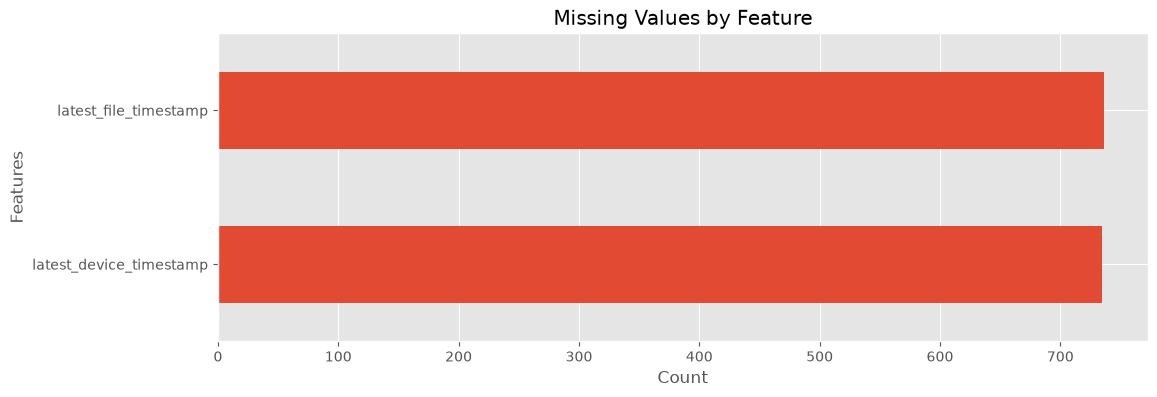

In [8]:
if len(missing) == 0:
    print("No missing values found in the feature dataset.")
else:
    plt.figure(figsize=(12, 4))
    missing.sort_values().plot(kind="barh")
    plt.title("Missing Values by Feature")
    plt.xlabel("Count")
    plt.ylabel("Features")
    plt.show()

In [9]:
df.fillna(0, inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


# 5. Feature Categories

The behavioral dataset contains engineered features derived from different employee activities.

These features are grouped into five categories:

### Login Features
- Login Count
- Unique PCs
- Weekend Logins
- After-hours Logins

### HTTP Features
- Website Visits
- Unique Websites
- Weekend HTTP Activity
- After-hours HTTP Activity

### Email Features
- Emails Sent
- External Emails
- After-hours Emails

### File Features
- File Access Count
- Unique Files
- Weekend File Access

### Device Features
- Device Usage Count
- Connect Events
- Disconnect Events
- Weekend Device Usage

These engineered features provide the behavioral information used by the Random Forest classifier for insider threat prediction.

In [10]:
print("Behavior Feature Columns\n")

for column in df.columns:
    print(column)

Behavior Feature Columns

employee_id
login_count
unique_pc_count
weekend_logins
after_hours_logins
average_login_hour
first_login
last_login
latest_login_timestamp
http_visit_count
unique_websites
after_hours_http
weekend_http
unique_http_pcs
latest_http_timestamp
email_sent
external_emails
after_hours_emails
latest_email_timestamp
file_access_count
unique_files
after_hours_file_access
weekend_file_access
latest_file_timestamp
device_usage_count
connect_count
disconnect_count
after_hours_device_usage
weekend_device_usage
latest_device_timestamp
event_timestamp


# 6. Dynamic Risk Threshold Generation

Instead of using fixed values, this project calculates dynamic behavioral thresholds using the **95th percentile** of selected behavioral features.

Dynamic thresholds adapt automatically to the distribution of employee activity within the CERT dataset, making the model more flexible and reducing dependence on manually selected values.

In [11]:
print("=" * 60)
print("CALCULATING DYNAMIC RISK THRESHOLDS")
print("=" * 60)

http_threshold = df["http_visit_count"].quantile(0.95)

email_threshold = df["external_emails"].quantile(0.95)

device_threshold = df["device_usage_count"].quantile(0.95)

file_threshold = df["file_access_count"].quantile(0.95)

print(f"HTTP Threshold           : {http_threshold}")

print(f"External Email Threshold : {email_threshold}")

print(f"Device Threshold         : {device_threshold}")

print(f"File Threshold           : {file_threshold}")

CALCULATING DYNAMIC RISK THRESHOLDS
HTTP Threshold           : 56099.39999999996
External Email Threshold : 2600.25
Device Threshold         : 2004.1
File Threshold           : 2321.5999999999995


# 7. Risk Score Generation

The CERT dataset does not directly provide a binary target suitable for our model.

Therefore, a behavioral **risk score** is calculated using suspicious employee activities.

Each risky behavior contributes one point to the overall risk score.

Employees with higher behavioral scores are classified as potential insider threats.

In [12]:
risk_score = (

    (df["after_hours_logins"] >= 5).astype(int)

    + (df["weekend_logins"] >= 3).astype(int)

    + (df["http_visit_count"] >= http_threshold).astype(int)

    + (df["external_emails"] >= email_threshold).astype(int)

    + (df["device_usage_count"] >= device_threshold).astype(int)

    + (df["file_access_count"] >= file_threshold).astype(int)

)

df["risk_score"] = risk_score

df[["employee_id", "risk_score"]].head()

,employee_id,risk_score
0,AAE0190,0
1,AAF0535,0
2,AAF0791,0
3,AAL0706,0
4,AAM0658,1


# 8. Target Label Creation

Employees are categorized into two classes:

- **0 → Low Risk**
- **1 → High Risk**

Employees with a behavioral risk score greater than or equal to **2** are labeled as High Risk.

In [13]:
df["target"] = (df["risk_score"] >= 2).astype(int)

print("Target Label Distribution")

df["target"].value_counts()

Target Label Distribution


target
0    874
1    126
Name: count, dtype: int64

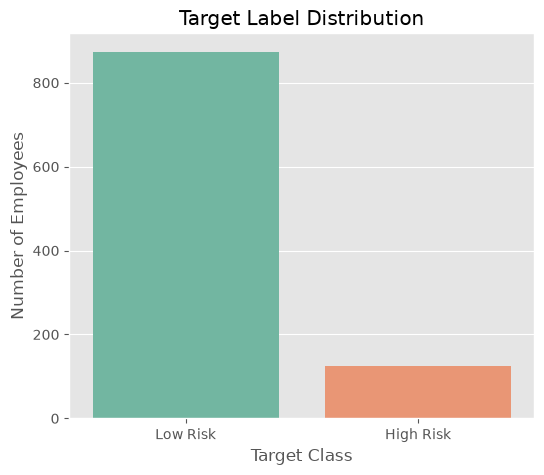

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["target"],
    palette="Set2"
)

plt.title("Target Label Distribution")

plt.xlabel("Target Class")

plt.ylabel("Number of Employees")

plt.xticks([0,1],["Low Risk","High Risk"])

plt.show()

The generated target labels represent the behavioral risk category assigned to each employee.

These labels are later used as the supervised learning target during Random Forest training.

# 9. Behavioral Feature Selection

The machine learning model is trained using engineered behavioral features extracted from employee activities.

These features summarize employee behavior across login, HTTP, email, file access, and device usage.

In [15]:
FEATURE_COLUMNS = [

    "login_count",
    "unique_pc_count",
    "weekend_logins",
    "after_hours_logins",

    "http_visit_count",
    "unique_websites",
    "after_hours_http",
    "weekend_http",
    "unique_http_pcs",

    "email_sent",
    "external_emails",
    "after_hours_emails",

    "file_access_count",
    "unique_files",
    "after_hours_file_access",
    "weekend_file_access",

    "device_usage_count",
    "connect_count",
    "disconnect_count",
    "after_hours_device_usage",
    "weekend_device_usage",

]

print(f"Total Features : {len(FEATURE_COLUMNS)}")

FEATURE_COLUMNS

Total Features : 21


['login_count',
 'unique_pc_count',
 'weekend_logins',
 'after_hours_logins',
 'http_visit_count',
 'unique_websites',
 'after_hours_http',
 'weekend_http',
 'unique_http_pcs',
 'email_sent',
 'external_emails',
 'after_hours_emails',
 'file_access_count',
 'unique_files',
 'after_hours_file_access',
 'weekend_file_access',
 'device_usage_count',
 'connect_count',
 'disconnect_count',
 'after_hours_device_usage',
 'weekend_device_usage']

# 10. Correlation Analysis

The correlation matrix provides insight into relationships between engineered behavioral features.

Strong correlations may indicate similar behavioral patterns, while weak correlations suggest independent information.

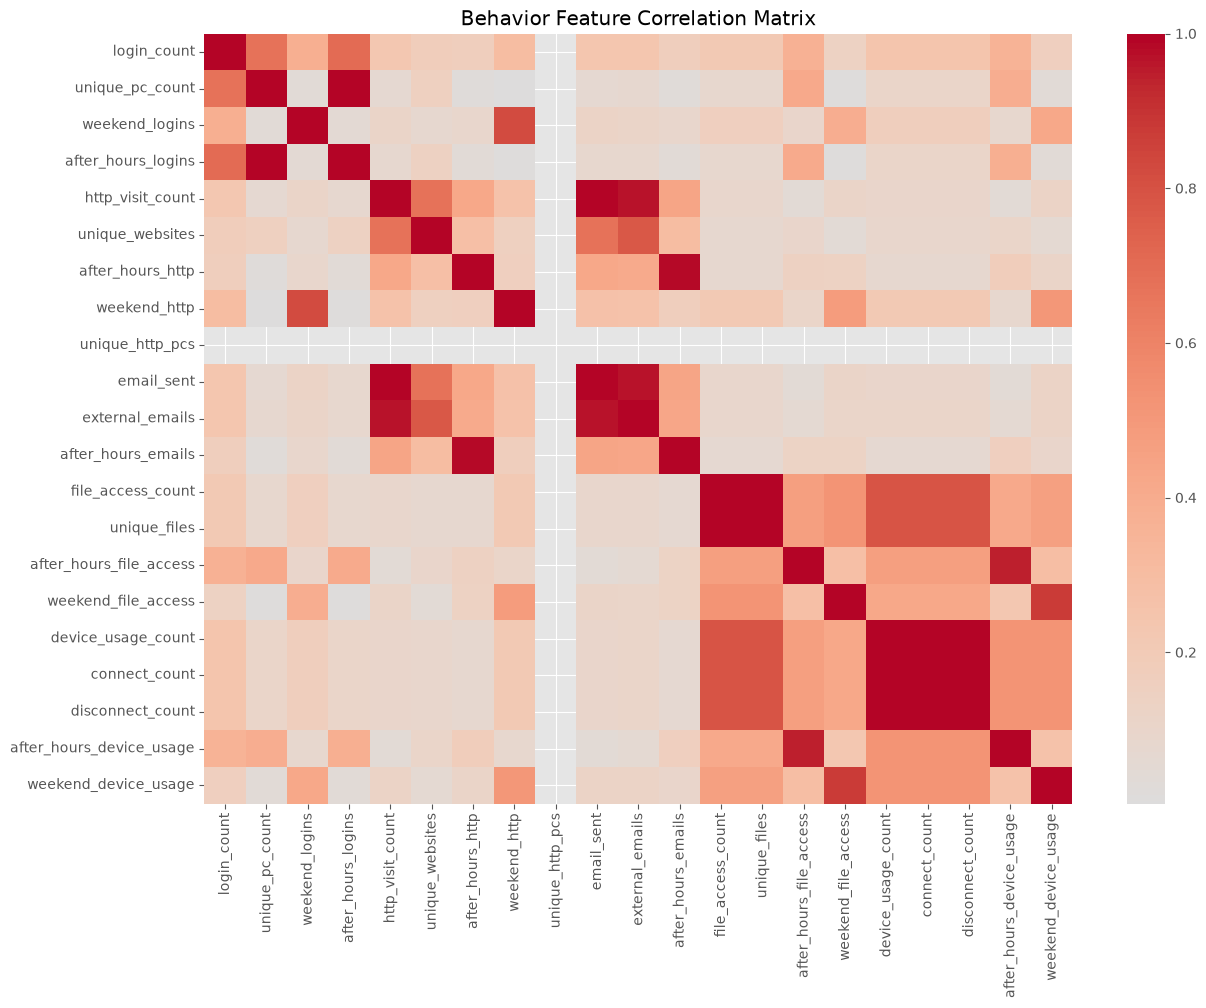

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(

    df[FEATURE_COLUMNS].corr(),

    cmap="coolwarm",

    center=0

)

plt.title("Behavior Feature Correlation Matrix")

plt.show()

# 11. Prepare Training Data

The selected behavioral features are separated into:

- Input Features (X)
- Target Labels (y)

These datasets are used for machine learning model training.

In [17]:
X = df[FEATURE_COLUMNS]

y = df["target"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (1000, 21)
Target Shape : (1000,)


# 12. Train-Test Split

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

Stratified sampling is used to preserve the original class distribution.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(f"Training Samples : {len(X_train)}")

print(f"Testing Samples : {len(X_test)}")

Training Samples : 800
Testing Samples : 200


# 13. Random Forest Model Training

A Random Forest Classifier is selected because it performs well on structured behavioral datasets.

Advantages include:

- Handles high-dimensional features
- Resistant to overfitting
- Good classification performance
- Provides feature importance
- Supports probability estimation

In [19]:
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# 14. Generate Predictions

The trained model predicts employee risk categories for the testing dataset.

In addition to class predictions, prediction confidence is calculated using class probabilities.

In [20]:
predictions = model.predict(X_test)

confidence = model.predict_proba(X_test).max(axis=1)

prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Prediction": predictions,

    "Confidence (%)": (confidence*100).round(2)

})

prediction_df.head(10)

,Actual,Prediction,Confidence (%)
0,0,0,100.0
1,0,0,100.0
2,1,1,93.0
3,0,0,100.0
4,0,0,100.0
5,0,0,100.0
6,0,0,100.0
7,1,1,89.0
8,0,0,100.0
9,0,0,98.0


# 15. Model Evaluation

After training the Random Forest classifier, the model is evaluated using several classification metrics.

The evaluation measures how accurately the model distinguishes between low-risk and high-risk employees.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix

In [21]:
accuracy = accuracy_score(y_test, predictions)

print("=" * 60)
print("MODEL ACCURACY")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

MODEL ACCURACY
Accuracy : 0.9850


In [22]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        predictions
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       175
           1       0.96      0.92      0.94        25

    accuracy                           0.98       200
   macro avg       0.97      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



The classification report summarizes the model's performance for each class.

It includes:

- Precision
- Recall
- F1-score
- Support

These metrics provide a detailed understanding of the model's ability to classify insider threat behavior.

In [23]:
cm = confusion_matrix(
    y_test,
    predictions
)

cm

array([[174,   1],
       [  2,  23]])

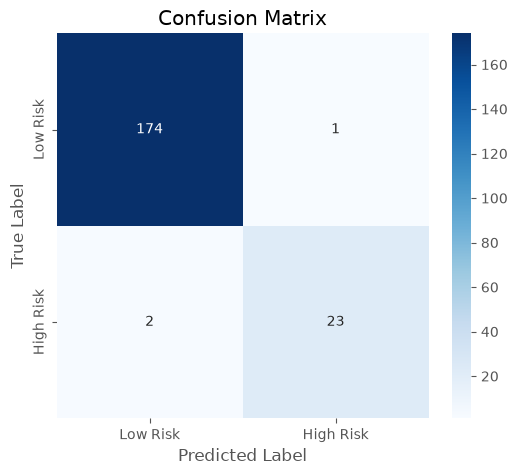

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks([0.5,1.5],["Low Risk","High Risk"])

plt.yticks([0.5,1.5],["Low Risk","High Risk"])

plt.show()

The confusion matrix illustrates the prediction performance of the model.

It shows:

- Correctly classified low-risk employees
- Correctly classified high-risk employees
- False positives
- False negatives

A well-performing model produces higher values along the diagonal of the matrix.

# 16. Feature Importance Analysis

One advantage of Random Forest is its ability to estimate feature importance.

Feature importance helps identify which employee behaviors contribute the most to insider threat prediction.

This improves model interpretability and supports explainable AI.

In [25]:
feature_importance = pd.DataFrame({

    "Feature": FEATURE_COLUMNS,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
2,weekend_logins,0.189737
3,after_hours_logins,0.122735
4,http_visit_count,0.121619
9,email_sent,0.096751
13,unique_files,0.072595
17,connect_count,0.055351
10,external_emails,0.049150
12,file_access_count,0.043367
16,device_usage_count,0.041832
7,weekend_http,0.036696


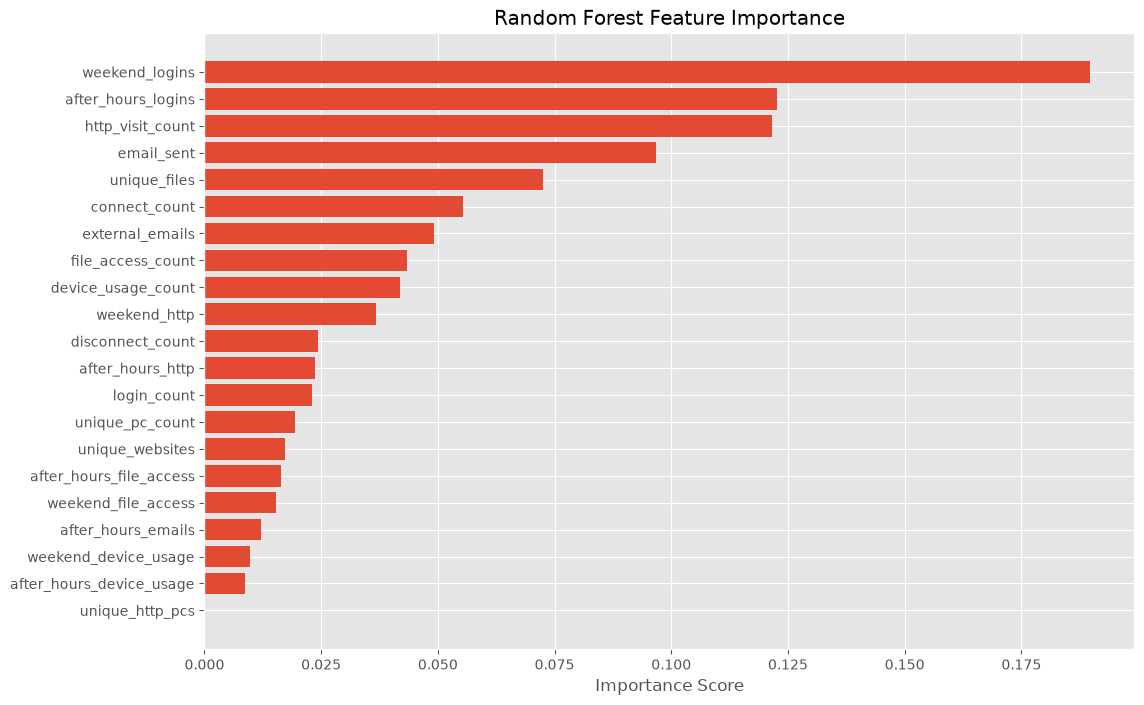

In [26]:
plt.figure(figsize=(12,8))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

The feature importance graph highlights the behavioral indicators that have the greatest influence on insider threat prediction.

Highly ranked features contribute more significantly to the model's decision-making process.

Understanding feature importance improves transparency and helps security analysts interpret model predictions.

# 17. Save Trained Model and Artifacts

After training, the machine learning artifacts are saved for deployment.

The saved files include:

- Trained Random Forest Model
- Feature Column List
- Feature Importance
- Training Metrics
- Confusion Matrix

These artifacts are later used by the prediction pipeline and dashboard.

In [27]:
MODEL_DIR = BASE_DIR / "model"

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(

    model,

    MODEL_DIR / "random_forest_model.pkl"

)

joblib.dump(

    FEATURE_COLUMNS,

    MODEL_DIR / "feature_columns.pkl"

)

feature_importance.to_csv(

    MODEL_DIR / "feature_importance.csv",

    index=False

)

pd.DataFrame({

    "Metric":["Accuracy"],

    "Value":[accuracy]

}).to_csv(

    MODEL_DIR / "training_metrics.csv",

    index=False

)

pd.DataFrame(

    cm

).to_csv(

    MODEL_DIR / "confusion_matrix.csv",

    index=False

)

print("All model artifacts saved successfully.")

All model artifacts saved successfully.


# 18. Summary

This notebook demonstrates the complete machine learning workflow for behavioral insider threat detection using the CERT Insider Threat Dataset.

The workflow includes:

- Loading behavioral features
- Exploratory Data Analysis
- Missing value handling
- Dynamic risk threshold calculation
- Risk score generation
- Target label creation
- Feature selection
- Random Forest training
- Prediction generation
- Model evaluation
- Feature importance analysis
- Saving trained model artifacts

The trained model forms the core of the AI Insider Threat Behavioral Intelligence System and is integrated with the FastAPI backend, automated prediction pipeline, PostgreSQL database, and React dashboard.

# Future Scope

The current implementation focuses on behavioral analysis using structured activity logs.

Future improvements may include:

- Deep Learning based anomaly detection
- Real-time streaming data analysis
- Sequence modeling using LSTM or Transformer architectures
- Graph-based user behavior analysis
- Explainable AI dashboards
- Continuous model retraining
- Risk trend forecasting
- Integration with enterprise SIEM platforms

These enhancements can further improve the accuracy, scalability, and real-time capabilities of insider threat detection systems.